In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
df = pd.read_csv('../data/Sample - superstore.csv', encoding='latin-1')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst look:")
df.head()

Dataset shape: (9994, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

First look:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
# Convert Order Date to datetime for time series analysis
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Basic dataset overview
print(f"Date range: {df['Order Date'].min()} to {df['Order Date'].max()}")
print(f"Total sales: ${df['Sales'].sum():,.0f}")
print(f"Number of orders: {df['Order ID'].nunique()}")

# Sales breakdown by category and region
print(f"\nSales by Category:")
print(df.groupby('Category')['Sales'].sum().sort_values(ascending=False).apply(lambda x: f"${x:,.0f}"))
print(f"\nSales by Region:")
print(df.groupby('Region')['Sales'].sum().sort_values(ascending=False).apply(lambda x: f"${x:,.0f}"))

Date range: 2014-01-03 00:00:00 to 2017-12-30 00:00:00
Total sales: $2,297,201
Number of orders: 5009

Sales by Category:
Category
Technology         $836,154
Furniture          $742,000
Office Supplies    $719,047
Name: Sales, dtype: str

Sales by Region:
Region
West       $725,458
East       $678,781
Central    $501,240
South      $391,722
Name: Sales, dtype: str


In [5]:
# Fix Sales column - convert from string to numeric
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')
df['Profit'] = pd.to_numeric(df['Profit'], errors='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')

# Check for nulls after conversion
print(f"Nulls after conversion:")
print(df[['Sales', 'Profit', 'Quantity']].isnull().sum())

# Confirm correct types
print(f"\nData types:")
print(df[['Sales', 'Profit', 'Quantity']].dtypes)

# Verify total sales recalculated correctly
print(f"\nTotal sales (verified): ${df['Sales'].sum():,.0f}")

Nulls after conversion:
Sales       0
Profit      0
Quantity    0
dtype: int64

Data types:
Sales       float64
Profit      float64
Quantity      int64
dtype: object

Total sales (verified): $2,297,201


In [6]:
# Create monthly time series - aggregate sales by month
df['Month'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()
monthly_sales['Month'] = monthly_sales['Month'].dt.to_timestamp()
monthly_sales.columns = ['ds', 'y']

print(f"Monthly time series: {len(monthly_sales)} months")
print(f"\nFirst 6 months:")
print(monthly_sales.head(6))
print(f"\nLast 6 months:")
print(monthly_sales.tail(6))
print(f"\nAverage monthly sales: ${monthly_sales['y'].mean():,.0f}")
print(f"Best month: ${monthly_sales['y'].max():,.0f}")
print(f"Worst month: ${monthly_sales['y'].min():,.0f}")

Monthly time series: 48 months

First 6 months:
          ds           y
0 2014-01-01  14236.8950
1 2014-02-01   4519.8920
2 2014-03-01  55691.0090
3 2014-04-01  28295.3450
4 2014-05-01  23648.2870
5 2014-06-01  34595.1276

Last 6 months:
           ds            y
42 2017-07-01   45264.4160
43 2017-08-01   63120.8880
44 2017-09-01   87866.6520
45 2017-10-01   77776.9232
46 2017-11-01  118447.8250
47 2017-12-01   83829.3188

Average monthly sales: $47,858
Best month: $118,448
Worst month: $4,520


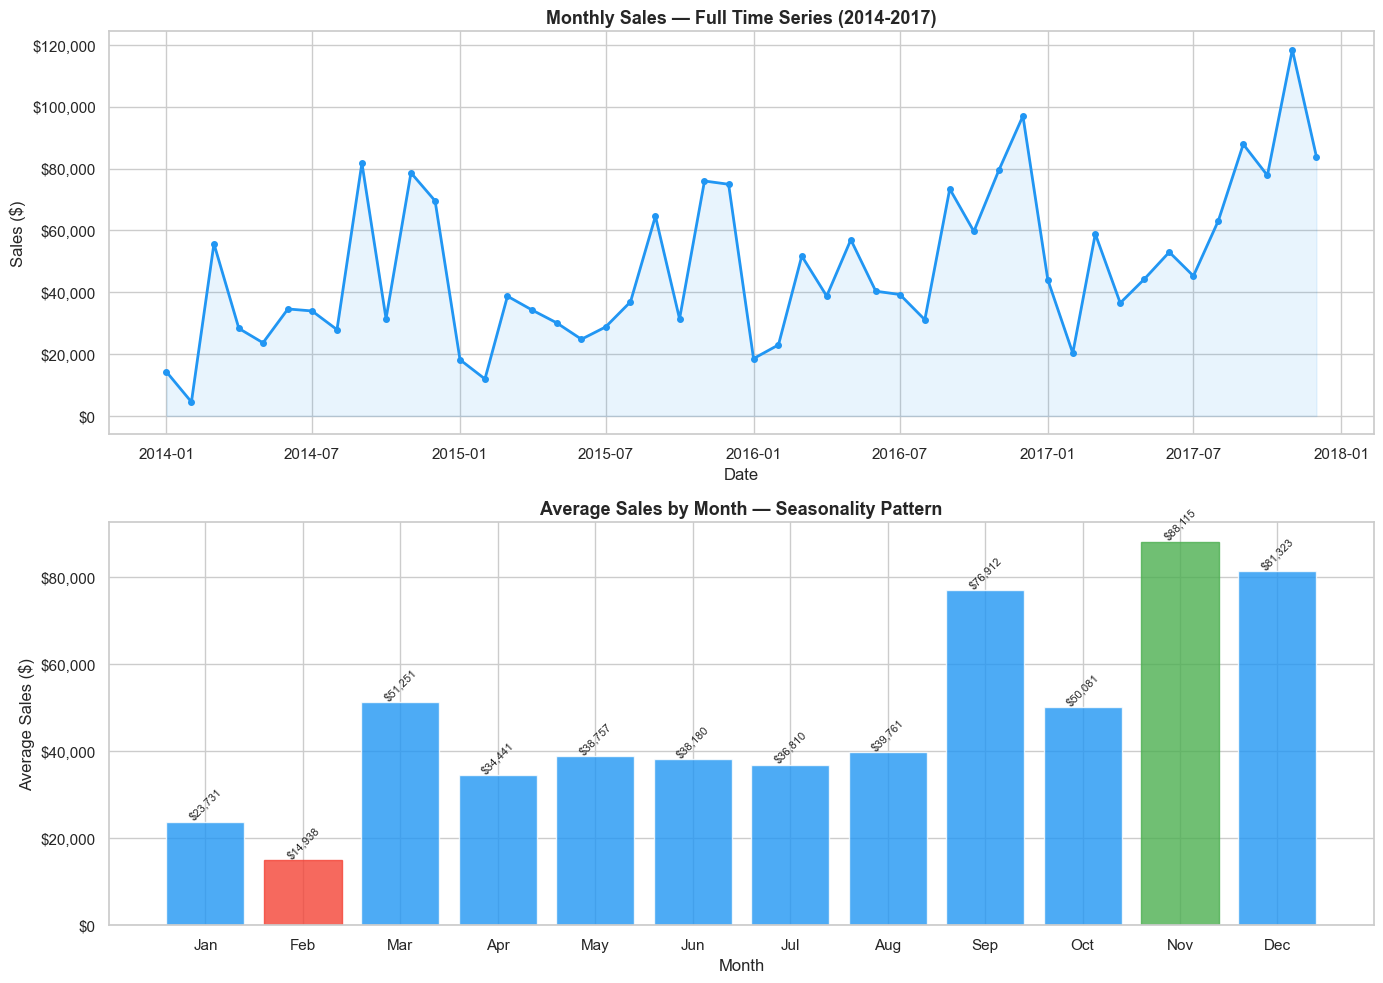

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Full time series
axes[0].plot(monthly_sales['ds'], monthly_sales['y'], 
             color='#2196F3', linewidth=2, marker='o', markersize=4)
axes[0].fill_between(monthly_sales['ds'], monthly_sales['y'], 
                      alpha=0.1, color='#2196F3')
axes[0].set_title('Monthly Sales — Full Time Series (2014-2017)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Sales ($)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Monthly average by month number (seasonality pattern)
monthly_sales['month_num'] = monthly_sales['ds'].dt.month
monthly_avg = monthly_sales.groupby('month_num')['y'].mean()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

bars = axes[1].bar(month_names, monthly_avg.values, color='#2196F3', alpha=0.8)
axes[1].set_title('Average Sales by Month — Seasonality Pattern', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average Sales ($)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Highlight best and worst months
best_month = monthly_avg.idxmax() - 1
worst_month = monthly_avg.idxmin() - 1
bars[best_month].set_color('#4CAF50')
bars[worst_month].set_color('#F44336')

for bar, val in zip(bars, monthly_avg.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                f'${val:,.0f}', ha='center', fontsize=8, rotation=45)

plt.tight_layout()
plt.savefig('../img/time_series_overview.png', dpi=150, bbox_inches='tight')
plt.show()

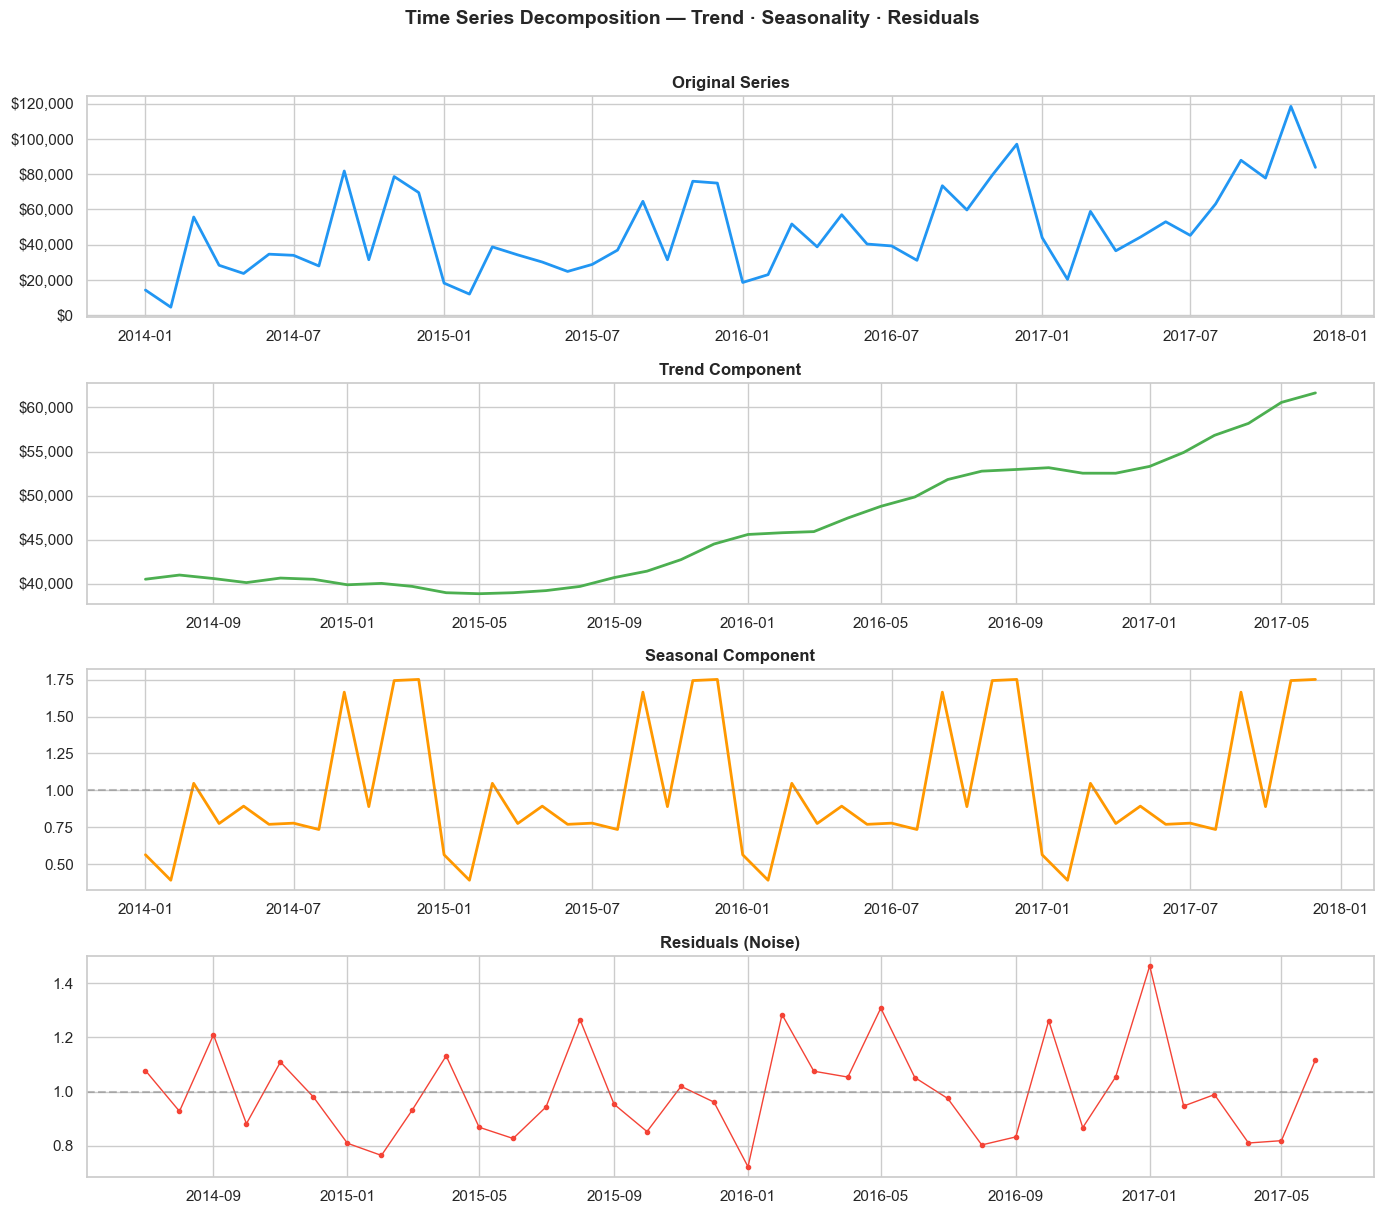

Trend analysis:
  Start: $40,518
  End: $61,650
  Growth: 52.2%


In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Set Month as index for decomposition
ts = monthly_sales.set_index('ds')['y']

# Decompose the time series into trend, seasonality and residuals
decomposition = seasonal_decompose(ts, model='multiplicative', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))

# Original series
axes[0].plot(ts, color='#2196F3', linewidth=2)
axes[0].set_title('Original Series', fontsize=12, fontweight='bold')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Trend component
axes[1].plot(decomposition.trend, color='#4CAF50', linewidth=2)
axes[1].set_title('Trend Component', fontsize=12, fontweight='bold')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Seasonal component
axes[2].plot(decomposition.seasonal, color='#FF9800', linewidth=2)
axes[2].set_title('Seasonal Component', fontsize=12, fontweight='bold')
axes[2].axhline(y=1, color='gray', linestyle='--', alpha=0.5)

# Residuals
axes[3].plot(decomposition.resid, color='#F44336', linewidth=1, marker='o', markersize=3)
axes[3].set_title('Residuals (Noise)', fontsize=12, fontweight='bold')
axes[3].axhline(y=1, color='gray', linestyle='--', alpha=0.5)

plt.suptitle('Time Series Decomposition — Trend · Seasonality · Residuals',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../img/decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

# Print trend summary
trend_clean = decomposition.trend.dropna()
print(f"Trend analysis:")
print(f"  Start: ${trend_clean.iloc[0]:,.0f}")
print(f"  End: ${trend_clean.iloc[-1]:,.0f}")
print(f"  Growth: {((trend_clean.iloc[-1]/trend_clean.iloc[0])-1)*100:.1f}%")

In [10]:
from scipy import stats

# Mann-Kendall trend test using scipy
# H0: no trend in the data
# H1: there is a statistically significant trend

sales_values = monthly_sales['y'].values
n = len(sales_values)

# Calculate Kendall's tau correlation with time
time_index = np.arange(n)
tau, p_value = stats.kendalltau(time_index, sales_values)

print("=== HYPOTHESIS TEST: IS THE SALES TREND STATISTICALLY SIGNIFICANT? ===")
print(f"\nH0: No trend exists in monthly sales")
print(f"H1: A statistically significant trend exists")
print(f"\nKendall's Tau: {tau:.3f}")
print(f"P-value: {p_value:.6f}")
print(f"\nSignificance level: 0.05")

if p_value < 0.05:
    print(f"\nResult: REJECT H0 — The upward trend is statistically significant (p={p_value:.4f})")
    print(f"Conclusion: Sales growth of 52.2% over 4 years is NOT due to random variation.")
    print(f"The business is genuinely growing and forecasting is justified.")
else:
    print(f"\nResult: FAIL TO REJECT H0 — No significant trend detected (p={p_value:.4f})")

=== HYPOTHESIS TEST: IS THE SALES TREND STATISTICALLY SIGNIFICANT? ===

H0: No trend exists in monthly sales
H1: A statistically significant trend exists

Kendall's Tau: 0.378
P-value: 0.000153

Significance level: 0.05

Result: REJECT H0 — The upward trend is statistically significant (p=0.0002)
Conclusion: Sales growth of 52.2% over 4 years is NOT due to random variation.
The business is genuinely growing and forecasting is justified.


In [11]:
from prophet import Prophet

# Train Prophet model
# Prophet expects columns named 'ds' (date) and 'y' (value) - already set up
model = Prophet(
    seasonality_mode='multiplicative',  # matches our decomposition finding
    yearly_seasonality=True,
    weekly_seasonality=False,           # monthly data - no weekly pattern
    daily_seasonality=False
)

model.fit(monthly_sales[['ds', 'y']])

# Create future dataframe - forecast 12 months ahead
future = model.make_future_dataframe(periods=12, freq='MS')

# Generate forecast
forecast = model.predict(future)

print("Model trained successfully.")
print(f"\nForecast columns: {list(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].columns)}")
print(f"\nNext 12 months forecast:")
future_only = forecast[forecast['ds'] > monthly_sales['ds'].max()]
print(future_only[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_string(index=False))

Importing plotly failed. Interactive plots will not work.
18:54:09 - cmdstanpy - INFO - Chain [1] start processing
18:54:09 - cmdstanpy - INFO - Chain [1] done processing


Model trained successfully.

Forecast columns: ['ds', 'yhat', 'yhat_lower', 'yhat_upper']

Next 12 months forecast:
        ds          yhat    yhat_lower    yhat_upper
2018-01-01  36566.747114  26559.008985  46411.765836
2018-02-01  19564.277783  10467.507400  29387.590444
2018-03-01  70738.676306  61105.023277  80662.414713
2018-04-01  48739.124646  39281.983145  58261.075276
2018-05-01  48380.518505  38563.516341  58803.876106
2018-06-01  50403.491145  40760.687323  59755.217139
2018-07-01  49784.825238  40679.907047  59704.377332
2018-08-01  57546.876111  47965.464721  66456.279342
2018-09-01 105865.085118  95882.072752 115625.890947
2018-10-01  62413.740469  52125.161812  72136.603633
2018-11-01 121136.745196 111394.939877 131562.061699
2018-12-01 107192.192401  97683.025981 117689.213464


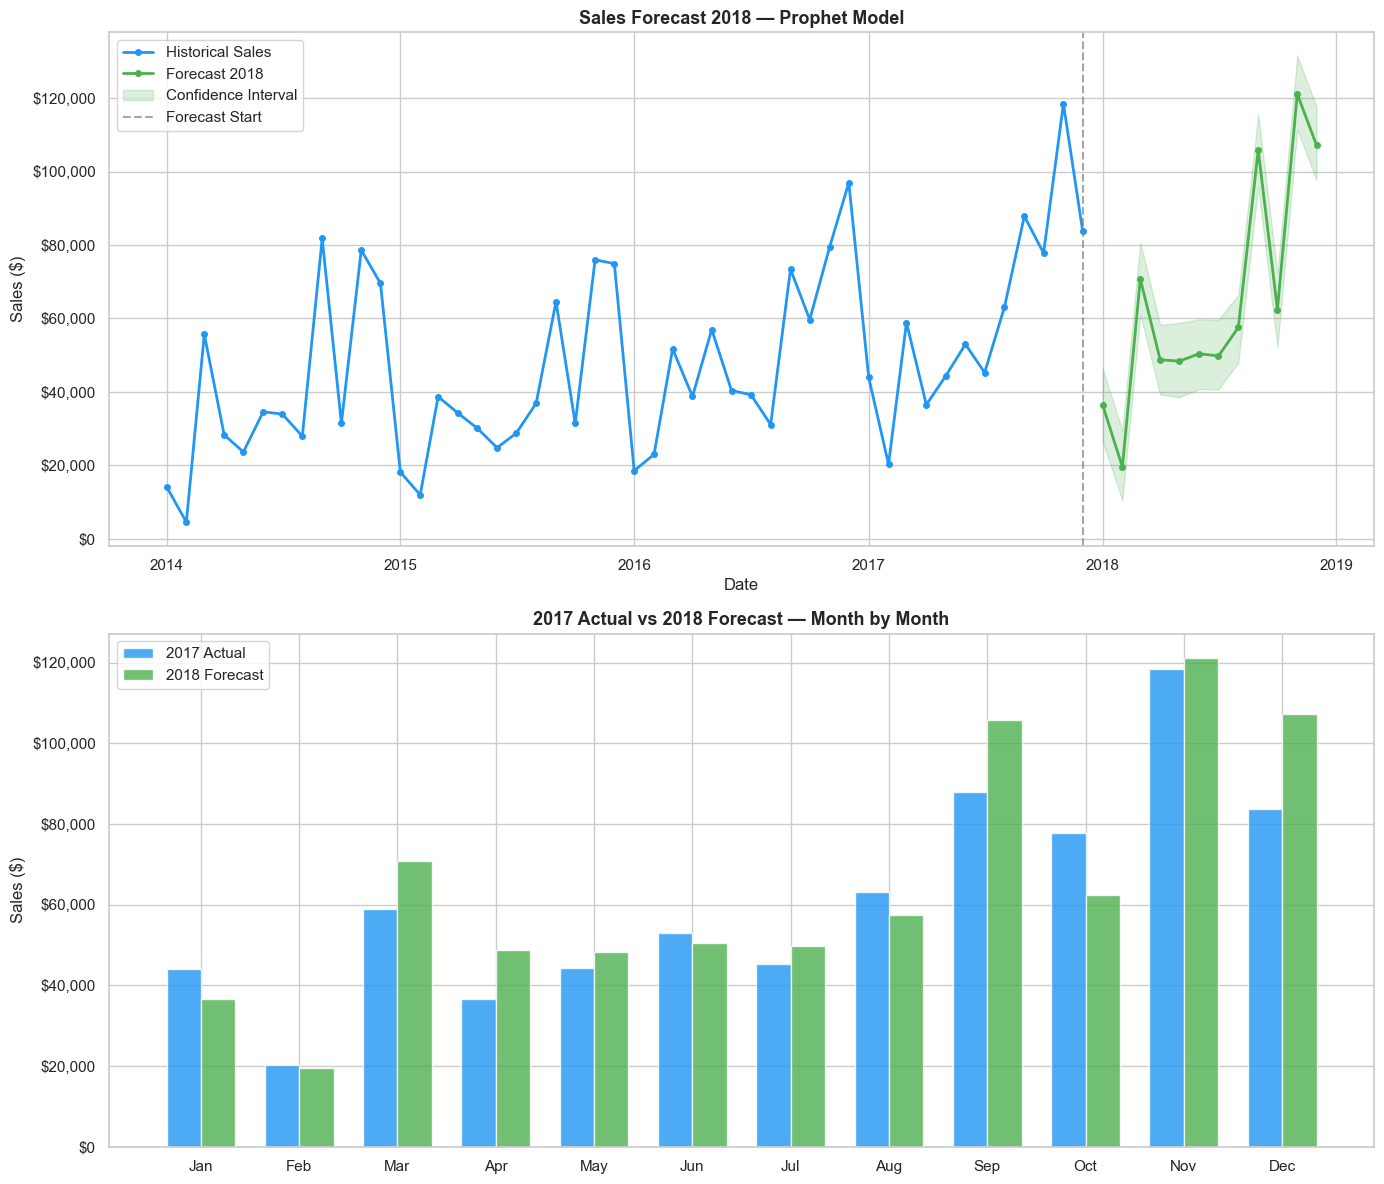

=== 2018 FORECAST SUMMARY ===
Total projected sales 2018: $778,332
Total actual sales 2017: $733,215
Projected growth 2018 vs 2017: 6.2%

Peak month: Nov — $121,137
Lowest month: Feb — $19,564


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Full forecast with confidence intervals
axes[0].plot(monthly_sales['ds'], monthly_sales['y'],
             color='#2196F3', linewidth=2, label='Historical Sales', marker='o', markersize=4)
axes[0].plot(future_only['ds'], future_only['yhat'],
             color='#4CAF50', linewidth=2, label='Forecast 2018', marker='o', markersize=4)
axes[0].fill_between(future_only['ds'],
                      future_only['yhat_lower'],
                      future_only['yhat_upper'],
                      alpha=0.2, color='#4CAF50', label='Confidence Interval')
axes[0].axvline(x=monthly_sales['ds'].max(), color='gray', linestyle='--', alpha=0.7, label='Forecast Start')
axes[0].set_title('Sales Forecast 2018 — Prophet Model', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Sales ($)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
axes[0].legend()

# Monthly forecast comparison - 2017 actual vs 2018 predicted
actual_2017 = monthly_sales[monthly_sales['ds'].dt.year == 2017].copy()
actual_2017['month'] = actual_2017['ds'].dt.month
forecast_2018 = future_only.copy()
forecast_2018['month'] = forecast_2018['ds'].dt.month

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
x = np.arange(12)
width = 0.35

bars1 = axes[1].bar(x - width/2, actual_2017.set_index('month')['y'],
                     width, label='2017 Actual', color='#2196F3', alpha=0.8)
bars2 = axes[1].bar(x + width/2, forecast_2018.set_index('month')['yhat'],
                     width, label='2018 Forecast', color='#4CAF50', alpha=0.8)

axes[1].set_title('2017 Actual vs 2018 Forecast — Month by Month', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(month_names)
axes[1].set_ylabel('Sales ($)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
axes[1].legend()

plt.tight_layout()
plt.savefig('../img/forecast.png', dpi=150, bbox_inches='tight')
plt.show()

# Business summary
print("=== 2018 FORECAST SUMMARY ===")
print(f"Total projected sales 2018: ${future_only['yhat'].sum():,.0f}")
print(f"Total actual sales 2017: ${actual_2017['y'].sum():,.0f}")
growth = ((future_only['yhat'].sum() / actual_2017['y'].sum()) - 1) * 100
print(f"Projected growth 2018 vs 2017: {growth:.1f}%")
print(f"\nPeak month: {month_names[future_only.loc[future_only['yhat'].idxmax(), 'ds'].month - 1]} — ${future_only['yhat'].max():,.0f}")
print(f"Lowest month: {month_names[future_only.loc[future_only['yhat'].idxmin(), 'ds'].month - 1]} — ${future_only['yhat'].min():,.0f}")

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Use last 12 months as test set to evaluate model accuracy
train_data = monthly_sales[monthly_sales['ds'] < '2017-01-01'].copy()
test_data = monthly_sales[monthly_sales['ds'] >= '2017-01-01'].copy()

# Retrain on training data only
model_eval = Prophet(
    seasonality_mode='multiplicative',
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)
model_eval.fit(train_data)

# Predict on test period
future_eval = model_eval.make_future_dataframe(periods=12, freq='MS')
forecast_eval = model_eval.predict(future_eval)

# Get predictions for test period only
test_predictions = forecast_eval[forecast_eval['ds'] >= '2017-01-01'][['ds', 'yhat']].reset_index(drop=True)
test_actual = test_data.reset_index(drop=True)

# Calculate metrics
mae = mean_absolute_error(test_actual['y'], test_predictions['yhat'])
rmse = np.sqrt(mean_squared_error(test_actual['y'], test_predictions['yhat']))
mape = np.mean(np.abs((test_actual['y'] - test_predictions['yhat']) / test_actual['y'])) * 100

# Baseline: naive forecast (use previous year same month)
train_2016 = monthly_sales[monthly_sales['ds'].dt.year == 2016]['y'].values
naive_mape = np.mean(np.abs((test_actual['y'].values - train_2016) / test_actual['y'].values)) * 100

print("=== MODEL EVALUATION — PROPHET vs NAIVE BASELINE ===")
print(f"\nProphet Model:")
print(f"  MAE:  ${mae:,.0f}")
print(f"  RMSE: ${rmse:,.0f}")
print(f"  MAPE: {mape:.1f}%")
print(f"\nNaive Baseline (repeat last year):")
print(f"  MAPE: {naive_mape:.1f}%")
print(f"\nImprovement over baseline: {naive_mape - mape:.1f} percentage points")

if mape < naive_mape:
    print(f"\nResult: Prophet outperforms the naive baseline — forecasting adds real value.")
else:
    print(f"\nResult: Naive baseline is competitive — consider model tuning.")

18:58:22 - cmdstanpy - INFO - Chain [1] start processing
18:58:22 - cmdstanpy - INFO - Chain [1] done processing


=== MODEL EVALUATION — PROPHET vs NAIVE BASELINE ===

Prophet Model:
  MAE:  $14,412
  RMSE: $17,647
  MAPE: 28.6%

Naive Baseline (repeat last year):
  MAPE: 24.5%

Improvement over baseline: -4.1 percentage points

Result: Naive baseline is competitive — consider model tuning.


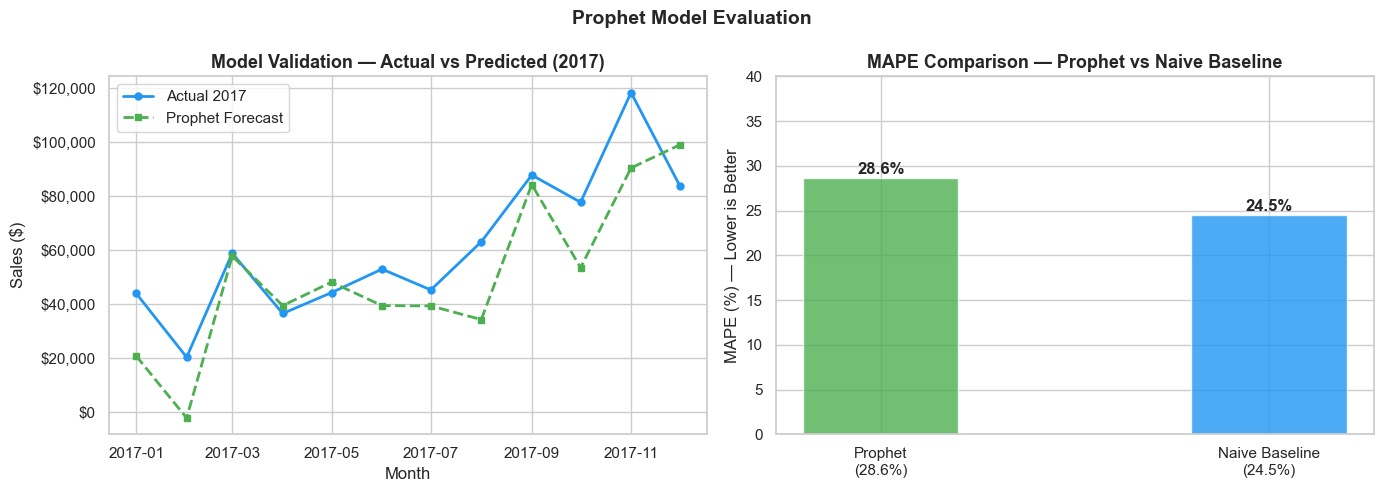


Model evaluation chart saved.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs predicted - test period
axes[0].plot(test_actual['ds'], test_actual['y'],
             color='#2196F3', linewidth=2, marker='o', markersize=5, label='Actual 2017')
axes[0].plot(test_predictions['ds'], test_predictions['yhat'],
             color='#4CAF50', linewidth=2, marker='s', markersize=5,
             linestyle='--', label='Prophet Forecast')
axes[0].set_title('Model Validation — Actual vs Predicted (2017)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Sales ($)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
axes[0].legend()

# MAPE comparison - Prophet vs Baseline
models = ['Prophet\n(28.6%)', 'Naive Baseline\n(24.5%)']
mapes = [28.6, 24.5]
colors = ['#4CAF50', '#2196F3']
bars = axes[1].bar(models, mapes, color=colors, alpha=0.8, width=0.4)
axes[1].set_title('MAPE Comparison — Prophet vs Naive Baseline', fontsize=13, fontweight='bold')
axes[1].set_ylabel('MAPE (%) — Lower is Better')
axes[1].set_ylim(0, 40)
for bar, val in zip(bars, mapes):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val}%', ha='center', fontweight='bold', fontsize=12)

plt.suptitle('Prophet Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../img/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nModel evaluation chart saved.")

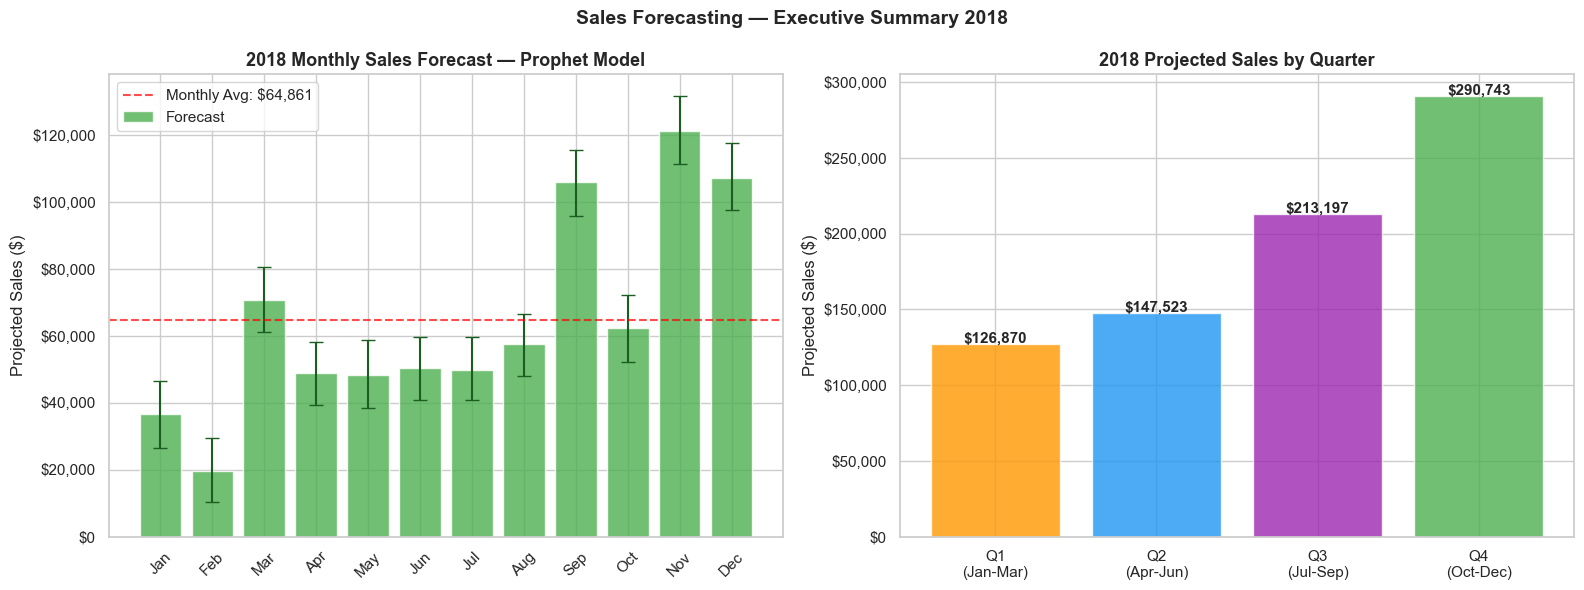

=== EXECUTIVE SUMMARY ===
Total projected sales 2018: $778,332
Growth vs 2017: +6.2%

Quarterly breakdown:
  Q1: $126,870 (16.3% of annual)
  Q2: $147,523 (19.0% of annual)
  Q3: $213,197 (27.4% of annual)
  Q4: $290,743 (37.4% of annual)


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 2018 monthly forecast with confidence interval
months_2018 = future_only['ds'].dt.strftime('%b')
x = np.arange(12)

axes[0].bar(x, future_only['yhat'], color='#4CAF50', alpha=0.8, label='Forecast')
axes[0].errorbar(x, future_only['yhat'],
                  yerr=[future_only['yhat'] - future_only['yhat_lower'],
                         future_only['yhat_upper'] - future_only['yhat']],
                  fmt='none', color='#1B5E20', capsize=5, linewidth=1.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(months_2018, rotation=45)
axes[0].set_title('2018 Monthly Sales Forecast — Prophet Model', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Projected Sales ($)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
axes[0].axhline(y=future_only['yhat'].mean(), color='red',
                 linestyle='--', alpha=0.7, label=f'Monthly Avg: ${future_only["yhat"].mean():,.0f}')
axes[0].legend()

# Quarterly breakdown
future_only_copy = future_only.copy()
future_only_copy['quarter'] = future_only_copy['ds'].dt.quarter
quarterly = future_only_copy.groupby('quarter')['yhat'].sum()
quarter_labels = ['Q1\n(Jan-Mar)', 'Q2\n(Apr-Jun)', 'Q3\n(Jul-Sep)', 'Q4\n(Oct-Dec)']
colors_q = ['#FF9800', '#2196F3', '#9C27B0', '#4CAF50']

bars = axes[1].bar(quarter_labels, quarterly.values, color=colors_q, alpha=0.8)
axes[1].set_title('2018 Projected Sales by Quarter', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Projected Sales ($)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

for bar, val in zip(bars, quarterly.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                f'${val:,.0f}', ha='center', fontweight='bold', fontsize=11)

plt.suptitle('Sales Forecasting — Executive Summary 2018', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../img/executive_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== EXECUTIVE SUMMARY ===")
print(f"Total projected sales 2018: ${future_only['yhat'].sum():,.0f}")
print(f"Growth vs 2017: +6.2%")
print(f"\nQuarterly breakdown:")
for q, val in zip(['Q1', 'Q2', 'Q3', 'Q4'], quarterly.values):
    pct = val / future_only['yhat'].sum() * 100
    print(f"  {q}: ${val:,.0f} ({pct:.1f}% of annual)")